In [234]:

import astropy.units as u

R = 8.314472 * u.J / (u.mol * u.K)
T_init = 273.15 * u.K
P_init = 264.96 * u.Pa
N_A = 6.022140e23  / u.mol
n = (P_init * N_A / (R * T_init)).to(u.m**-3)

k_B = 1.380658e-23 * u.m**2 * u.kg / (u.s**2 * u.K)
n_2 = (P_init / (k_B * T_init)).to(u.m**-3)

print(n)
print(n_2)

7.025791910216458e+22 1 / m3
7.025754926017738e+22 1 / m3


In [235]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [236]:
# parameters for hard sphere interactions
omega = 0.5
# corresponds to isotropic scattering
alpha = 1
mu_inf_mu_1 = 1.016034
mu_1_mu_inf =  1 / mu_inf_mu_1
mu_ref = 2.117e-5

m = 66.3e-27

k_B = 1.380658e-23
T_init = 273.15
numerator =  5 * (alpha + 1) * (alpha + 2) * np.sqrt(m * k_B * T_init / np.pi)
denominator = 4 * alpha * (5 - 2 * omega) * (7 - 2 * omega) * mu_ref * (mu_1_mu_inf)
d_ref =  np.sqrt(numerator / denominator)
print(f"Reference Diameter : {d_ref:0.4E}")
pressure = 264.96
N_A = 6.022140e23
R = 8.314472
density = pressure * N_A / (R * T_init)
lambda_0 =  1 / (np.sqrt(2) * np.pi * d_ref**2 * density)
print(f"Lambda_0           : {lambda_0:0.4E}")

L = 1e-3
cell_counts = 200
dx = L / cell_counts
dx_tilde = dx / lambda_0
print(f"Delta x tilde      : {dx_tilde:0.4E}")

c_0 = np.sqrt(2 * k_B * T_init / m)
print(f"c_0                : {c_0:0.4E}")
dt = 5e-8
t_0 = lambda_0 / c_0

dt_tilde = dt / t_0
print(f"Delta t tilde      : {dt_tilde:0.4E}")

Reference Diameter : 3.6579E-10
Lambda_0           : 2.3943E-05
Delta x tilde      : 2.0883E-01
c_0                : 3.3729E+02
Delta t tilde      : 7.0436E-01


In [237]:
def q_wall(dt_tilde, dx_tilde):
  factor = 1 + 0.0281 * dt_tilde**2
  factor += 0.0399 * dx_tilde**2
  factor -= 0.0011 * dx_tilde**4
  factor -= 0.0170 * dt_tilde**2 * dx_tilde**2
  factor += 0.0083 * dt_tilde**4 * dx_tilde**2
  return 1512 * factor

expected_q_wall = q_wall(dt_tilde, dx_tilde)

In [238]:
def trueSolution(x, T_mid, delta_T):
  T_min = T_mid - delta_T / 2.0
  return T_min + (delta_T) / (x.max() - x.min()) * x

In [239]:
import os
print(os.getcwd())

data = pd.read_csv("30_ppe/run_0_average_temperature_4001.csv")

/Users/gallgs/projects/salamander/fourier-flow


0 Simulations Failed


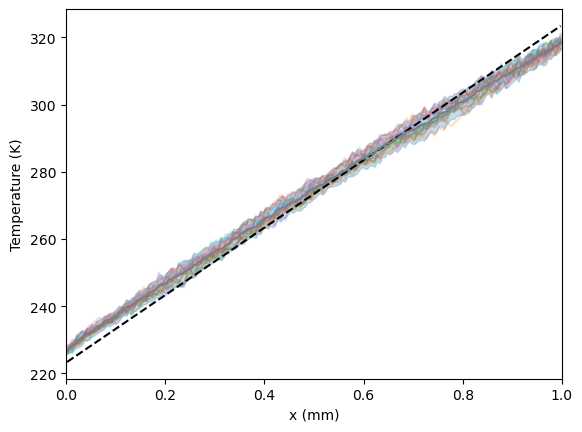

In [240]:

average = None
x_vals = None
runs = 17

T_mid = 273.15
delta_T = 100
show_all = True
all_temps = None
fails = 0
left_fluxes = np.zeros((runs))
right_fluxes = np.zeros((runs))

plt.figure()
for i in range(runs):
  data = pd.read_csv(f"30_ppe/run_{i:d}_average_temperature_6001.csv")
  flux_data = pd.read_csv(f"30_ppe/run_{i:d}.csv")
  if np.isnan(flux_data["left_heat_flux"].to_numpy()[0]) or np.isnan(flux_data["right_heat_flux"].to_numpy()[0]):
    fails += 1
    continue
  left_fluxes[i - fails] = flux_data["left_heat_flux"].to_numpy()[0]
  right_fluxes[i - fails] = flux_data["right_heat_flux"].to_numpy()[0]
  temperature = data["time_averaged_temperature"].to_numpy()
  if i == 0:
    all_temps = np.zeros((runs, len(temperature)))
    x_vals = data["x"].to_numpy() * 1e3
  all_temps[i - fails, :] = temperature
  if show_all:
    plt.plot(x_vals, data["time_averaged_temperature"], label=f"Run {i}", alpha=0.25)

if fails != 0:
  T_average = all_temps[:-fails].mean(axis=0)
  T_std = all_temps[:-fails].std(axis=0)
else :
  T_average = all_temps.mean(axis=0)
  T_std = all_temps.std(axis=0)
print(f"{fails:d} Simulations Failed")
plt.plot(x_vals, trueSolution(x_vals, T_mid, delta_T), 'k--', label="Continuum" )
plt.plot(x_vals, T_average, label='Simulated')
plt.fill_between(x_vals, T_average - 2 * T_std, T_average + 2 * T_std, color='tab:blue', alpha=0.25)
#plt.ylim(bottom=T_mid - delta_T / 2, top =T_mid + delta_T / 2)
plt.xlim(left=0, right=1)
plt.xlabel("x (mm)")
plt.ylabel("Temperature (K)")
#plt.legend()
#plt.axvline(0.5)
#plt.axhline(273.15)
plt.show()

In [ ]:
if fails != 0:
  mean_left_flux = left_fluxes[:-fails].mean()
  std_left_flux = left_fluxes[:-fails].std()
  mean_right_flux = right_fluxes[:-fails].mean()
  std_right_flux = right_fluxes[:-fails].std()
  all_fluxes = np.concat((left_fluxes[:-fails], np.abs(right_fluxes[:-fails])))
else:
  mean_left_flux = left_fluxes.mean()
  std_left_flux = left_fluxes.std()
  mean_right_flux = right_fluxes.mean()
  std_right_flux = right_fluxes.std()
  all_fluxes = np.concat((left_fluxes, np.abs(right_fluxes)))

print(f"Expected wall heat flux : {expected_q_wall}")
print(f"Left wall heat flux     : {mean_left_flux} +- {2 * std_left_flux}")
print(f"Right wall heat flux    : {mean_right_flux} +- {2 * std_right_flux}")
print(f"Both Mean wall flux     : {all_fluxes.mean()} +- {2 * all_fluxes.std()}")

Expected wall heat flux : 1535.2852567172554
Left wall heat flux     : 1568.8855659484354 +- 129.7344680841789
Right wall heat flux    : -1585.398463582206 +- 107.59727115610205
Both Mean wall flux     : 1577.1420147653205 +- 120.31948417827297
